In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 │ ⚙️ CONFIG + LOAD DATASET (DIRECT QA - RULE BASED ONLY)
# ─────────────────────────────────────────────────────────────────────────────
import json
import os
from pathlib import Path
import random
import re

# ── Target Model Config ──────────────────────────────────────────────────────
MODEL_NAME = "/home/drnguyenvinh/Exam-Assistant/Bench_mark/models/qwen3_examassist_merged_4b_rslora_domain_v3"
DATASET_PATH = "data/test-final_v3.jsonl"

RANDOM_SEED = 42
MAX_NEW_TOKENS = 128
TEMPERATURE = 0.0
BATCH_SIZE = 8
MAX_MODEL_LEN = 2048
GPU_MEM_UTIL = 0.85  # Có thể tăng lên vì không cần chia VRAM cho Judge LLM

RUN_NAME = "qwen3_vl_4b_finetuned_qa_rule"
OUTPUT_DIR = Path(f"./benchmark_outputs/{RUN_NAME}")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())


# Hàm trích xuất riêng câu hỏi (bỏ Context nếu có)
def extract_question_only(user_content):
    user_content = str(user_content).strip()
    question_match = re.search(
        r"(?:Question|Câu hỏi)\s*:\s*(.*)",
        user_content,
        flags=re.DOTALL | re.IGNORECASE,
    )
    if question_match:
        return question_match.group(1).strip()
    return user_content


samples = []
with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for idx, line in enumerate(f):
        item = json.loads(line)
        messages = item["messages"]

        system_msg = messages[0]["content"].strip()
        user_msg = messages[1]["content"].strip()
        gold_answer = messages[2]["content"].strip()

        question = extract_question_only(user_msg)

        samples.append(
            {
                "id": f"sample_{idx}",
                "question": question,
                "gold_answers": [gold_answer],  # Hỗ trợ list nếu có nhiều đáp án chuẩn
                "gold_answer": gold_answer,
                "messages": [
                    {"role": "system", "content": system_msg},
                    {"role": "user", "content": user_msg},
                ],
            }
        )

print(f"Loaded {len(samples)} samples successfully.")
print("Example Question:", samples[0]["question"])
print("Example Gold Answer:", samples[0]["gold_answer"])

OUTPUT_DIR: /home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/qwen3_vl_4b_finetuned_qa_rule
Loaded 430 samples successfully.
Example Question: Tài khoản đăng nhập EOS là tài khoản nào?
Example Gold Answer: Tài khoản đăng nhập EOS/PEA chính là tài khoản Wi-Fi FU-Student của sinh viên.


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 | LOAD QWEN3-VL-4B-INSTRUCT WITH vLLM (SAFE TOKENIZER PATCH)
# ─────────────────────────────────────────────────────────────────────────────
import io
import os
os.environ["VLLM_ENABLE_V1_MULTIPROCESSING"] = "0"
os.environ["VLLM_USE_FLASHINFER_SAMPLER"] = "0"
import subprocess
import sys
from transformers import AutoTokenizer
from vllm import LLM, SamplingParams


def _patch_jupyter_streams():
    _null_fd = os.open(os.devnull, os.O_WRONLY)

    class _FilenoPatchedStream:

        def __init__(self, original, null_fd):
            object.__setattr__(self, "_orig", original)
            object.__setattr__(self, "_null_fd", null_fd)

        def fileno(self):
            return object.__getattribute__(self, "_null_fd")

        def write(self, s):
            return object.__getattribute__(self, "_orig").write(s)

        def flush(self):
            return object.__getattribute__(self, "_orig").flush()

        def isatty(self):
            return False

        def readable(self):
            return False

        def writable(self):
            return True

        def __getattr__(self, name):
            return getattr(object.__getattribute__(self, "_orig"), name)

    for stream_name in ("stdout", "stderr"):
        stream = getattr(sys, stream_name)
        try:
            stream.fileno()
        except io.UnsupportedOperation:
            setattr(sys, stream_name, _FilenoPatchedStream(stream, _null_fd))


_patch_jupyter_streams()

try:
    print(subprocess.getoutput("nvidia-smi"))
except Exception as e:
    print("Cannot run nvidia-smi:", e)

# 1. Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME, trust_remote_code=True, extra_special_tokens={}
)

# [FIX AN TOÀN] Gán trực tiếp thuộc tính thiếu bằng danh sách an toàn
if not hasattr(tokenizer, "all_special_tokens_extended"):
    try:
        extra_tokens = getattr(tokenizer, "additional_special_tokens", [])
    except Exception:
        extra_tokens = []
    tokenizer.all_special_tokens_extended = (
        tokenizer.all_special_tokens + extra_tokens
    )

print("Tokenizer loaded successfully with patch.")

# 2. Load vLLM Engine
llm = LLM(
    model=MODEL_NAME,
    trust_remote_code=True,
    dtype="half",
    quantization=None,
    max_model_len=MAX_MODEL_LEN,
    gpu_memory_utilization=GPU_MEM_UTIL,
    enforce_eager=True,
    max_num_seqs=BATCH_SIZE,
    limit_mm_per_prompt={"image": 0},
)

sampling_params = SamplingParams(
    temperature=TEMPERATURE, max_tokens=MAX_NEW_TOKENS
)

print("Model loaded successfully.")

WARNING 07-24 15:16:53 [config.py:70] Support for Transformers v4 is deprecated. The Transformers v4 codepath will become unmaintained in vLLM v0.22.0 and will be removed in vLLM v0.24.0. Please upgrade to Transformers v5: pip install --upgrade transformers
Fri Jul 24 15:16:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:01:00.0  On

Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


INFO 07-24 15:17:00 [default_loader.py:397] Loading weights took 1.69 seconds
INFO 07-24 15:17:00 [gpu_model_runner.py:5132] Model loading took 8.69 GiB memory and 1.988870 seconds
INFO 07-24 15:17:00 [gpu_model_runner.py:6136] Encoder cache will be initialized with a budget of 8192 tokens, and profiled with 1 video items of the maximum feature size.
INFO 07-24 15:17:03 [gpu_worker.py:466] Available KV cache memory: 10.23 GiB
INFO 07-24 15:17:03 [kv_cache_utils.py:1733] GPU KV cache size: 74,464 tokens
INFO 07-24 15:17:03 [kv_cache_utils.py:1734] Maximum concurrency for 2,048 tokens per request: 36.36x
INFO 07-24 15:17:03 [jit_monitor.py:54] Kernel JIT monitor activated — Triton JIT compilations during inference will be logged as warnings.
INFO 07-24 15:17:03 [core.py:309] init engine (profile, create kv cache, warmup model) took 2.45 s
Model loaded successfully.


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 │ 🔮 INFERENCE
# ─────────────────────────────────────────────────────────────────────────────
import time
from tqdm import tqdm

prompts = []

for s in samples:
    prompt = tokenizer.apply_chat_template(
        s["messages"],
        tokenize=False,
        add_generation_prompt=True
    )
    prompts.append(prompt)

print("Total prompts:", len(prompts))
print("Prompt preview:")
print(prompts[0][:1000])

start_time = time.time()

outputs = llm.generate(
    prompts,
    sampling_params,
    use_tqdm=True
)

total_time = time.time() - start_time

predictions = [
    output.outputs[0].text.strip()
    for output in outputs
]

for s, pred in zip(samples, predictions):
    s["prediction"] = pred

print("✅ Inference completed")
print("Total time:", round(total_time, 2), "seconds")
print("Avg latency:", round(total_time / len(samples), 4), "sec/sample")
print("Throughput:", round(len(samples) / total_time, 2), "samples/sec")

print("\nPrediction example:")
print(predictions[0])

Total prompts: 430
Prompt preview:
<|im_start|>system
Bạn là trợ lý AI hỗ trợ giám thị coi thi. Chỉ trả lời dựa trên ngữ cảnh được cung cấp. Trả lời ngắn gọn, chính xác và không suy diễn ngoài dữ liệu.<|im_end|>
<|im_start|>user
Context:
Sự cố 01. Tài khoản đăng nhập EOS và quản lý mật khẩu. Trong kỳ thi EOS, mạng Wi-Fi sử dụng để làm bài là FU-Exam với mật khẩu FU-Exam@. Tài khoản đăng nhập hệ thống thi EOS/PEA chính là tài khoản Wi-Fi FU-Student của sinh viên. Do đó, nếu sinh viên quên mật khẩu đăng nhập EOS thì cần kiểm tra hoặc đặt lại mật khẩu tài khoản Wi-Fi FU-Student. Nếu sinh viên không nhớ mật khẩu Wi-Fi FU-Student, trước tiên cần kiểm tra hộp thư email bằng cách tìm kiếm các từ khóa như Wifi, EOS, IT, Account hoặc Pass để tìm email chứa thông tin tài khoản do nhà trường gửi. Nếu cần đổi mật khẩu, sinh viên truy cập http://reset.fun.cantho/, nhập tài khoản đăng nhập và địa chỉ email để nhận mật khẩu tạm thời. Sau khi nhận email, sinh viên quay lại trang reset, nhập Username, 

Rendering prompts:   0%|          | 0/430 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/430 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

WARNING 07-24 15:17:03 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _compute_slot_mapping_kernel. This causes a latency spike; consider extending warmup to cover this shape/config.


Processed prompts:  99%|█████████▉| 427/430 [00:12<00:00, 39.76it/s, est. speed input: 11455.44 toks/s, output: 624.73 toks/s]

WARNING 07-24 15:17:15 [jit_monitor.py:103] Triton kernel JIT compilation during inference: _triton_mrope_forward. This causes a latency spike; consider extending warmup to cover this shape/config.


Processed prompts: 100%|██████████| 430/430 [00:12<00:00, 35.13it/s, est. speed input: 11323.39 toks/s, output: 622.51 toks/s]

✅ Inference completed
Total time: 12.44 seconds
Avg latency: 0.0289 sec/sample
Throughput: 34.56 samples/sec

Prediction example:
Tài khoản Wi-Fi FU-Student.


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 │ 🧹 GIẢI PHÓNG VRAM CỦA MODEL INFERENCE TRƯỚC KHI LOAD JUDGE MODEL
#            (bắt buộc để tránh OOM khi chạy 2 model vLLM tuần tự trên cùng 1 GPU)
# ─────────────────────────────────────────────────────────────────────────────
import gc
import torch

def unload_vllm(llm_instance):
    """Giải phóng toàn bộ VRAM đang bị vLLM giữ (weights + KV cache)."""
    try:
        from vllm.distributed.parallel_state import (
            destroy_model_parallel,
            destroy_distributed_environment,
        )
        destroy_model_parallel()
        destroy_distributed_environment()
    except Exception as e:
        print("Cảnh báo khi destroy vLLM parallel state:", e)

    try:
        del llm_instance.llm_engine.model_executor
    except Exception:
        pass

    del llm_instance
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

unload_vllm(llm)
del llm
gc.collect()
torch.cuda.empty_cache()

print("Đã giải phóng VRAM của model inference.")
print(subprocess.getoutput("nvidia-smi"))

Đã giải phóng VRAM của model inference.
Fri Jul 24 15:17:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4090        Off |   00000000:01:00.0  On |                  Off |
| 35%   59C    P2            279W /  450W |   20438MiB /  24564MiB |    100%      Default |
|                                         |                        |                  N/A |
+-------

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 │ 📊 EVALUATION METRICS (EM, F1, ROUGE-L, CONTAINMENT, REFUSAL/HALLUCINATION)
# ─────────────────────────────────────────────────────────────────────────────
from collections import Counter
import re
import unicodedata
import numpy as np
import pandas as pd


def normalize_text(text):
    text = str(text).lower().strip()
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"[^\w\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def compute_em(pred, gold):
    return int(normalize_text(pred) == normalize_text(gold))


def compute_f1(pred, gold):
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()
    if not pred_tokens and not gold_tokens:
        return 1.0
    if not pred_tokens or not gold_tokens:
        return 0.0
    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0.0
    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)
    return 2 * (precision * recall) / (precision + recall)


def lcs_length(x, y):
    dp = [[0] * (len(y) + 1) for _ in range(len(x) + 1)]
    for i in range(1, len(x) + 1):
        for j in range(1, len(y) + 1):
            if x[i - 1] == y[j - 1]:
                dp[i][j] = dp[i - 1][j - 1] + 1
            else:
                dp[i][j] = max(dp[i - 1][j], dp[i][j - 1])
    return dp[-1][-1]


def compute_rouge_l(pred, gold):
    pred_tokens = normalize_text(pred).split()
    gold_tokens = normalize_text(gold).split()
    if not pred_tokens or not gold_tokens:
        return 0.0
    lcs = lcs_length(pred_tokens, gold_tokens)
    precision = lcs / len(pred_tokens)
    recall = lcs / len(gold_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * (precision * recall) / (precision + recall)


def compute_containment(pred, gold):
    norm_pred = normalize_text(pred)
    norm_gold = normalize_text(gold)
    if not norm_gold:
        return 0
    return int(norm_gold in norm_pred)


print("Đang tính toán các chỉ số benchmark...")
rows = []

for s in samples:
    pred = s["prediction"]
    gold = s["gold_answer"]
    gold_answers_all = s.get("gold_answers", [gold])
    is_unanswerable = bool(s.get("is_unanswerable", False))

    em = max(compute_em(pred, g) for g in gold_answers_all)
    f1 = max(compute_f1(pred, g) for g in gold_answers_all)
    rouge_l = max(compute_rouge_l(pred, g) for g in gold_answers_all)
    containment = max(compute_containment(pred, g) for g in gold_answers_all)

    pred_tokens_count = len(tokenizer.encode(pred, add_special_tokens=False))
    pred_words_count = len(pred.split())
    gold_words_count = len(gold.split())

    rows.append({
        "id": s["id"], "question": s["question"], "gold_answer": gold,
        "prediction": pred, "is_unanswerable": is_unanswerable,
        "em": em, "f1": f1,
        "rouge_l": rouge_l, "containment": containment,
        "pred_len_tokens": pred_tokens_count, "pred_len_words": pred_words_count,
        "gold_len_words": gold_words_count,
    })

df = pd.DataFrame(rows)
answerable_df = df[~df["is_unanswerable"]].copy()
unanswerable_df = df[df["is_unanswerable"]].copy()

num_samples = len(df)
avg_latency_sec = total_time / max(num_samples, 1)
throughput_sps = num_samples / total_time if total_time > 0 else 0

summary = {
    "model": MODEL_NAME.split("/")[-1],
    "samples": num_samples,
    "answerable_samples": int(len(answerable_df)),
    "unanswerable_samples": int(len(unanswerable_df)),
    "answerable_em": round(answerable_df["em"].mean() * 100, 2) if len(answerable_df) else 0.0,
    "answerable_f1": round(answerable_df["f1"].mean() * 100, 2) if len(answerable_df) else 0.0,
    "answerable_rouge_l": round(answerable_df["rouge_l"].mean() * 100, 2) if len(answerable_df) else 0.0,
    "answerable_containment": round(answerable_df["containment"].mean() * 100, 2) if len(answerable_df) else 0.0,
    "overall_em": round(df["em"].mean() * 100, 2),
    "overall_f1": round(df["f1"].mean() * 100, 2),
    "overall_rouge_l": round(df["rouge_l"].mean() * 100, 2),
    "avg_latency_sec": round(avg_latency_sec, 4),
    "throughput_samples_per_sec": round(throughput_sps, 2),
    "total_time_sec": round(total_time, 2),
}
summary_df = pd.DataFrame([summary])

print("\n" + "=" * 70)
print("  BENCHMARK SUMMARY REPORT — DIRECT QA (RULE-BASED)")
print("=" * 70)
display(summary_df.T.rename(columns={0: "Value"}))

Đang tính toán các chỉ số benchmark...

  BENCHMARK SUMMARY REPORT — DIRECT QA (RULE-BASED)


,Value
model,qwen3_examassist_merged_4b_rslora_domain_v3
samples,430
answerable_samples,430
unanswerable_samples,0
answerable_em,19.07
answerable_f1,67.27
answerable_rouge_l,65.96
answerable_containment,27.67
overall_em,19.07
overall_f1,67.27


Saved fixed metrics:
benchmark_outputs/qwen3_vl_4b_finetuned_qa_rule/qwen_predictions_fixed_metrics.jsonl
benchmark_outputs/qwen3_vl_4b_finetuned_qa_rule/qwen_predictions_fixed_metrics.csv
benchmark_outputs/qwen3_vl_4b_finetuned_qa_rule/qwen_summary_fixed_metrics.csv
benchmark_outputs/qwen3_vl_4b_finetuned_qa_rule/qwen_summary_fixed_metrics.json


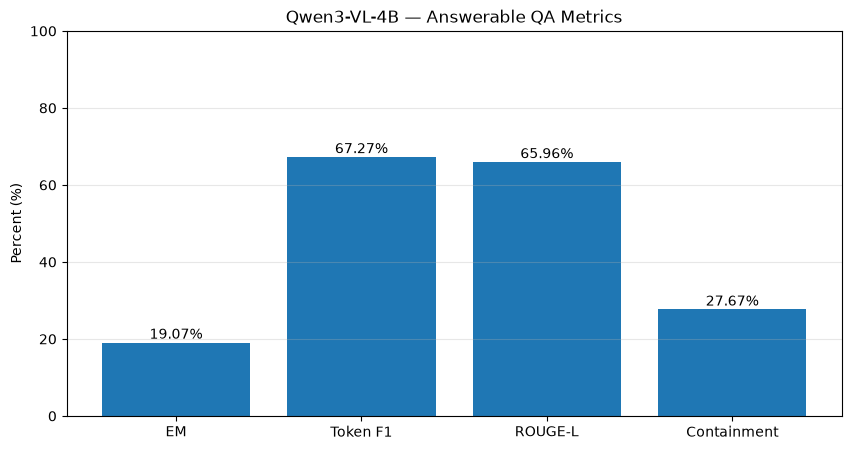

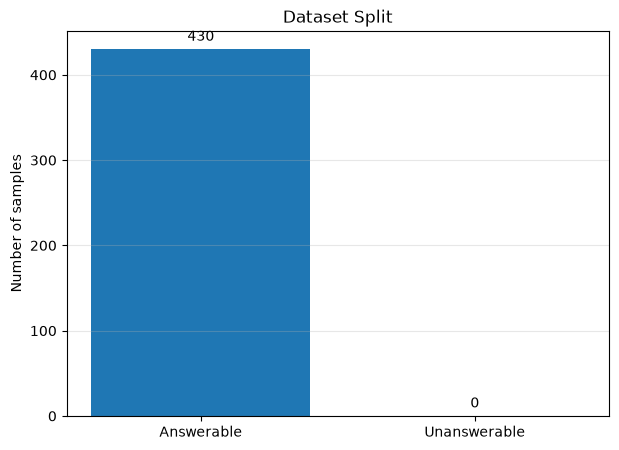

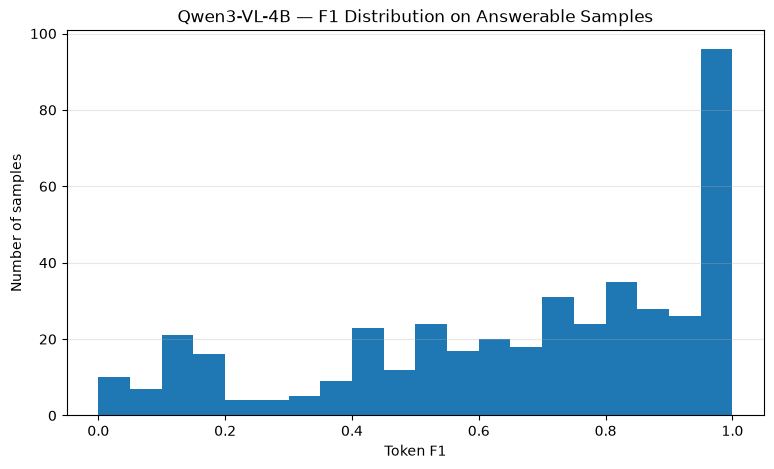


✅ Saved to: /home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/qwen3_vl_4b_finetuned_qa_rule


In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 │ 💾 SAVE RESULTS + CHARTS
# ─────────────────────────────────────────────────────────────────────────────
import json
import matplotlib.pyplot as plt

results_jsonl = OUTPUT_DIR / "qwen_predictions_fixed_metrics.jsonl"
results_csv = OUTPUT_DIR / "qwen_predictions_fixed_metrics.csv"
summary_csv = OUTPUT_DIR / "qwen_summary_fixed_metrics.csv"
summary_json = OUTPUT_DIR / "qwen_summary_fixed_metrics.json"

with open(results_jsonl, "w", encoding="utf-8") as f:
    for row in rows:
        f.write(json.dumps(row, ensure_ascii=False) + "\n")

df.to_csv(results_csv, index=False, encoding="utf-8-sig")
summary_df.to_csv(summary_csv, index=False, encoding="utf-8-sig")
with open(summary_json, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print("Saved fixed metrics:")
print(results_jsonl); print(results_csv); print(summary_csv); print(summary_json)

metric_names = ["EM", "Token F1", "ROUGE-L", "Containment"]
metric_values = [summary["answerable_em"], summary["answerable_f1"], summary["answerable_rouge_l"],
                  summary["answerable_containment"]]
plt.figure(figsize=(10, 5))
plt.bar(metric_names, metric_values)
plt.ylabel("Percent (%)"); plt.title("Qwen3-VL-4B — Answerable QA Metrics")
plt.ylim(0, 100); plt.grid(axis="y", alpha=0.3)
for i, v in enumerate(metric_values):
    plt.text(i, v + 1, f"{v:.2f}%", ha="center")
plt.savefig(OUTPUT_DIR / "qwen_answerable_metrics.png", dpi=200, bbox_inches="tight")
plt.show()

split_names = ["Answerable", "Unanswerable"]
split_values = [summary["answerable_samples"], summary["unanswerable_samples"]]
plt.figure(figsize=(7, 5))
plt.bar(split_names, split_values)
plt.ylabel("Number of samples"); plt.title("Dataset Split"); plt.grid(axis="y", alpha=0.3)
for i, v in enumerate(split_values):
    plt.text(i, v + 10, str(v), ha="center")
plt.savefig(OUTPUT_DIR / "dataset_split.png", dpi=200, bbox_inches="tight")
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(answerable_df["f1"], bins=20)
plt.xlabel("Token F1"); plt.ylabel("Number of samples")
plt.title("Qwen3-VL-4B — F1 Distribution on Answerable Samples")
plt.grid(axis="y", alpha=0.3)
plt.savefig(OUTPUT_DIR / "qwen_answerable_f1_distribution.png", dpi=200, bbox_inches="tight")
plt.show()

print("\n✅ Saved to:", OUTPUT_DIR.resolve())

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 │ 📝 SAVE BENCHMARK REPORT
# ─────────────────────────────────────────────────────────────────────────────
report_path = OUTPUT_DIR / "qwen_benchmark_report_fixed_metrics.md"

report = f"""# Benchmark Report — Qwen3-VL-4B-Instruct Baseline

## Model
`{MODEL_NAME}`

## Dataset
`{DATASET_PATH}`

Number of samples: **{len(df)}**
- Answerable samples: **{summary["answerable_samples"]}**
- Unanswerable samples: **{summary["unanswerable_samples"]}**

## Main Results

### Answerable QA
| Metric | Value |
|---|---:|
| Answerable EM | {summary["answerable_em"]:.2f}% |
| Answerable Token F1 | {summary["answerable_f1"]:.2f}% |
| Answerable ROUGE-L | {summary["answerable_rouge_l"]:.2f}% |
| Containment Accuracy | {summary["answerable_containment"]:.2f}% |


### Overall
| Metric | Value |
|---|---:|
| Overall EM | {summary["overall_em"]:.2f}% |
| Overall Token F1 | {summary["overall_f1"]:.2f}% |
| Overall ROUGE-L | {summary["overall_rouge_l"]:.2f}% |
| Average Latency | {summary["avg_latency_sec"]:.4f} sec/sample |
| Throughput | {summary["throughput_samples_per_sec"]:.2f} samples/sec |

## Interpretation
This benchmark follows a SQuAD2.0 / ViQuAD2.0-style evaluation because the dataset contains both answerable and unanswerable questions.

For answerable samples, EM, Token F1, ROUGE-L, and Containment Accuracy measure answer quality. Containment Accuracy is useful when the model generates a complete sentence while the gold answer is a short span.

For unanswerable samples, Correct Refusal Rate measures whether the model correctly refuses to answer. Hallucination Rate measures cases where the model produces an answer despite the gold label being unanswerable.

All metrics in this run are rule-based (no LLM-as-judge step).

## Output Files
- `qwen_predictions_fixed_metrics.jsonl`
- `qwen_predictions_fixed_metrics.csv`
- `qwen_summary_fixed_metrics.csv`
- `qwen_summary_fixed_metrics.json`
- `qwen_answerable_metrics.png`
- `dataset_split.png`
- `qwen_answerable_f1_distribution.png`
"""

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print("✅ Qwen fixed report saved:")
print(report_path.resolve())

✅ Qwen fixed report saved:
/home/drnguyenvinh/Exam-Assistant/Bench_mark/benchmark_outputs/qwen3_vl_4b_finetuned_qa_rule/qwen_benchmark_report_fixed_metrics.md


In [8]:
print(prompts[0])
print(predictions[0])

<|im_start|>system
Bạn là trợ lý AI hỗ trợ giám thị coi thi. Chỉ trả lời dựa trên ngữ cảnh được cung cấp. Trả lời ngắn gọn, chính xác và không suy diễn ngoài dữ liệu.<|im_end|>
<|im_start|>user
Context:
Sự cố 01. Tài khoản đăng nhập EOS và quản lý mật khẩu. Trong kỳ thi EOS, mạng Wi-Fi sử dụng để làm bài là FU-Exam với mật khẩu FU-Exam@. Tài khoản đăng nhập hệ thống thi EOS/PEA chính là tài khoản Wi-Fi FU-Student của sinh viên. Do đó, nếu sinh viên quên mật khẩu đăng nhập EOS thì cần kiểm tra hoặc đặt lại mật khẩu tài khoản Wi-Fi FU-Student. Nếu sinh viên không nhớ mật khẩu Wi-Fi FU-Student, trước tiên cần kiểm tra hộp thư email bằng cách tìm kiếm các từ khóa như Wifi, EOS, IT, Account hoặc Pass để tìm email chứa thông tin tài khoản do nhà trường gửi. Nếu cần đổi mật khẩu, sinh viên truy cập http://reset.fun.cantho/, nhập tài khoản đăng nhập và địa chỉ email để nhận mật khẩu tạm thời. Sau khi nhận email, sinh viên quay lại trang reset, nhập Username, Old Password (mật khẩu tạm thời), s

In [9]:
df["gold_len_words"].describe()
df["pred_len_words"].describe()
low_f1 = df.sort_values("f1").head(20)

for _, row in low_f1.iterrows():
    print("="*20)
    print("QUESTION:", row["question"])
    print("GOLD    :", row["gold_answer"])
    print("PRED    :", row["prediction"])
    print("F1      :", row["f1"])

QUESTION: Wi-Fi FU-Exam dùng tài khoản nào để đăng nhập?
GOLD    : Không có thông tin trong ngữ cảnh được cung cấp.
PRED    : Tài khoản Wi-Fi FU-Student.
F1      : 0.0
QUESTION: Sau khi tải lại EOS thì cần làm gì trước khi đăng nhập?
GOLD    : Giải nén phần mềm rồi đăng nhập lại.
PRED    : Lưu EOS trực tiếp trên Desktop hoặc ổ D.
F1      : 0.0
QUESTION: Nếu sinh viên đã được IT hỗ trợ nhưng vẫn không kết nối được Wi-Fi khi dùng USB thì làm gì?
GOLD    : Giám thị báo lên nhóm hỗ trợ chung kèm MSSV để bộ phận Khảo thí xác nhận và quyết định hướng xử lý.
PRED    : Không có thông tin trong ngữ cảnh được cung cấp.
F1      : 0.0
QUESTION: Nếu vẫn không kết nối được Wi-Fi sau khi restart máy thì ngoài VPN còn cần làm gì?
GOLD    : Thử khởi động lại card mạng trước khi chuyển sang các bước hỗ trợ tiếp theo.
PRED    : Cần kiểm tra xem máy tính còn cài đặt VPN hay không.
F1      : 0.0
QUESTION: Nếu không nộp bài được sau nhiều lần thử thì xử lý tiếp thế nào?
GOLD    : Hướng dẫn sinh viên gửi fil

In [10]:
refusal_gold = 0

for s in samples:
    gold = s["gold_answer"].lower()

    if "tôi không tìm thấy thông tin" in gold:
        refusal_gold += 1

print("Unanswerable samples:", refusal_gold)
print("Answerable samples:", len(samples)-refusal_gold)
print("Refusal ratio:", refusal_gold/len(samples)*100)

Unanswerable samples: 0
Answerable samples: 430
Refusal ratio: 0.0
